In [1]:
from qeep import plot

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax.numpy as jnp


In [2]:
configuration = '../../configs/abacus/config_desi_asymm.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)

pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

In [3]:
name = config["name"]

path = f"../../results/{name}/"

norm = np.load(path+f"analysis_theory_normalization_AB.npy", allow_pickle = True).item()
var = np.load(path+f"analysis_theory_variance_AB.npy", allow_pickle = True).item()
bis = np.load(path+f"analysis_theory_shot_bispectrum_AB.npy", allow_pickle = True).item()
tris = np.load(path+f"analysis_theory_shot_trispectrum_AB.npy", allow_pickle = True).item()

## Let's define the power spectra

In [4]:
from qeep import biases
from qeep import qeresults as qres
import jax
from jax import numpy as jnp

def plinear():
    return plinf(Ks)

def E_bottaro():
    z_eq = 3400
    a_eq = 1/(1+z_eq)
    a = 1.
    fchi = 1.
    factor = jnp.log(a/a_eq)-181/90
    factor *= fchi
    factor *= 6/5
    return factor

def G(epsilon, one = 1):
    E = E_bottaro()
    return 1+epsilon*E*one

def get_CG(v, asymm_shift = 1., only_asymm_shift = 0.):  
    """
    Effective biases.

    asymm_shift = 1., means we include the C^{S}_{[AB]} signature from the anti-symmetric term. If zero, this is not included.
    only_asymm_shift = 0., means that we are including G and T anti-symmetric. If 1., we exclude them. This is useful to check origin of constraints on epsilon.
    """
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    Cg = biases.get_Cg_biases(e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return Cg


def get_tot_bias_Cg(normalization, Cg, responses):
    """
    This is the overall bias coming from all the present terms, given Cg.
    """
    partials = normalization * responses * Cg[:, jnp.newaxis]
    bias = jnp.sum(partials, axis=0)
    return jnp.nan_to_num(bias)

def get_tot_bias(v, normalization, responses, asymm_shift = 1, only_asymm_shift = 0.):
    """
    This is the overall bias given your parameter vector v, the normalization of the estimator, and the responses.
    """
    Cg = get_CG(v, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    return get_tot_bias_Cg(normalization, Cg, responses)

def galaxy_power_spectrum(v, nshot, growth_eps = 1.):
    """
    Standard power spectrum with linear bias and shot noise.
    We also include an additional growth factor depending on epsilon.
    """
    eps, b1X = v
    return  b1X**2*plinear()*G(eps, growth_eps)**2 + nshot
    
def reconstruction_cross_spectrum(v, normalization, responses, bisp_noise, asymm_shift = 1, only_asymm_shift = 0., growth_eps = 1.):
    """
    bisp_noise, bispectrum shot noise
    growth_eps, include growth term epsilon or not
    """
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    b1X = v[1]
    signal = b1X*bias*plinear()*G(v[0], growth_eps)**3
    return signal + bisp_noise

def reconstruction_auto_spectrum(v, normalization, responses, var_noise, tris_noise, signal = 1., asymm_shift = 1, only_asymm_shift = 0, growth_eps = 1.):
    bias = get_tot_bias(v, normalization, responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)
    signal = bias**2*plinear()*signal*G(v[0], growth_eps)**4
    return signal + var_noise + tris_noise

In [5]:
QR = qres.QEResults(config)
responses_dict = QR.get_out_normalization_AB()
responses = qres.get_normalization_array("n", ["g", "s", "t", "ga", "sa", "ta"], Ks, responses_dict)

In [6]:
def get_functions(key, QR, shot_noise = 1., variance_factor = 1., bispectrum_factor = 1., trispectrum_factor = 1., asymm_shift = 1., only_asymm_shift = 0., growth_eps = 0., vfid = None, fiducial_auto = False, fiducial_cross = False, fiducial_power = False, keys = ["g", "s", "t", "ga", "sa", "ta"]):
    
    #e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v

    variance_noise = QR.get_get_variance()(key)*variance_factor
    bispectrum_noise = QR.get_get_bispectrum()(key)*bispectrum_factor if bispectrum_factor != 0 else 0
    trispectrum_noise = QR.get_get_trispectrum()(key)*trispectrum_factor if trispectrum_factor != 0 else 0
    normalization = QR.get_get_norm()(key)
    out_normalization_AB = QR.get_out_normalization_AB()
    
    responses = qres.get_normalization_array(key, keys, Ks, out_normalization_AB)
    
    CAR = lambda v: reconstruction_cross_spectrum(v if not fiducial_cross else vfid, normalization, responses, bispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets cross-spectrum
    
    CRR = lambda v: reconstruction_auto_spectrum(v if not fiducial_auto else vfid, normalization, responses, variance_noise, trispectrum_noise, asymm_shift = asymm_shift, growth_eps = growth_eps, only_asymm_shift = only_asymm_shift) #gets reconstruction auto-spectrum
    
    CAA = lambda v: galaxy_power_spectrum(v[:2] if not fiducial_power else vfid[:2], shot_noise, growth_eps = growth_eps) #gets galaxy auto-spectrum

    return CAA, CAR, CRR


def get_v(vA):
    e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = vA
    b1B, b2B, bs2B = b1A, b2A, bs2A
    v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    return v

def get_functions_vA_only(CAA, CAR, CRR):
        
    def CAA_(vA):
        return CAA(get_v(vA))

    def CAR_(vA):
            return CAR(get_v(vA))

    def CRR_(vA):
            return CRR(get_v(vA))

    return CAA_, CAR_, CRR_


def get_cov(CAAf, CARf, CRRf):
    @jax.jit
    def covariance_full(K_array, v):

        n_probes = 2

        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        CAR = CARf(v)
        
        C = C.at[:, 0, 0].set(CRRf(v))
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAAf(v))
        
        return C
    
    return covariance_full

def get_Ofuncs(CAAf, CARf, CRRf):
    Ofunc = lambda K_arr, v: CARf(v)
    variance_func = lambda K_arr, v: CAAf(v)*CRRf(v)+CARf(v)**2
    return Ofunc, variance_func

In [7]:
def b2_fit(b10):
    return 2*(0.412-2.143*b10 + 0.929*b10**2 + 0.008*b10**3)

/tmp/ipykernel_96354/884440336.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-1e-1)


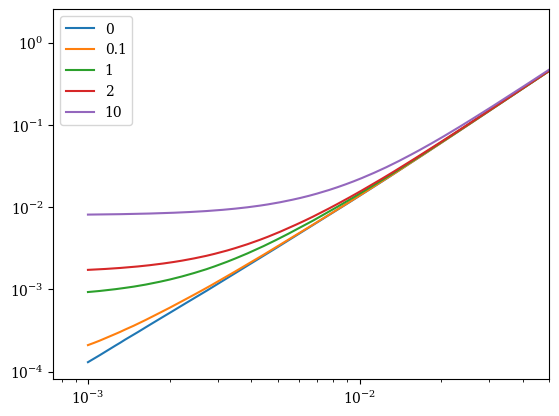

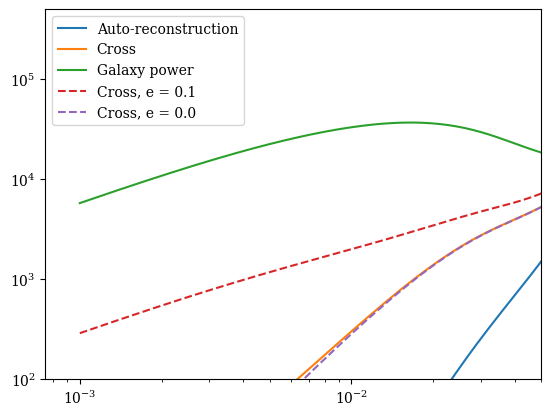

In [8]:
mainkey = "n"

biases_dict = config["bias"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3 #biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

keys = ["g", "s", "t", "ga", "sa", "ta"]

CAA, CAR, CRR = get_functions_vA_only(*get_functions(
    mainkey,
    QR,
    shot_noise=shot_noise,
    variance_factor=variance_factor,
    bispectrum_factor=bispectrum_factor,
    trispectrum_factor=trispectrum_factor,
    asymm_shift=asymm_shift,
    only_asymm_shift=only_asymm_shift,
    growth_eps=growth_eps,
    vfid=vfid,
    fiducial_auto=fiducial_auto,
    fiducial_cross=fiducial_cross,
    fiducial_power=fiducial_power,
    keys = keys
))

for x in [0, 1e-1, 1, 2, 10]:
    vB = jnp.array([x*e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
    bias_temp = get_tot_bias(get_v(vB), QR.get_get_norm()(mainkey), responses, asymm_shift = 1, only_asymm_shift = 0.)
    plt.loglog(Ks, bias_temp, label = x)
plt.xlim(xmax = 5e-2)
plt.ylim(-1e-1)
plt.yscale('symlog', linthresh = 1e-7)
plt.legend()
plt.show()

plt.loglog(Ks, CRR(vA), label = "Auto-reconstruction")
plt.loglog(Ks, (CAR(vA)), label = "Cross")
plt.loglog(Ks, CAA(vA), label = "Galaxy power")

e_ = 100*e
vB = jnp.array([e_, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
plt.loglog(Ks, CAR(vB), label = f"Cross, e = {e_}", ls = "--")

e_ = 0*e
vB = jnp.array([e_, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
plt.loglog(Ks, CAR(vB), label = f"Cross, e = {e_}", ls = "--")

plt.yscale('symlog', linthresh = 1e-6)
plt.xlim(xmax = 5e-2)
plt.ylim(ymin = 1e2)
plt.legend()
plt.show()

In [9]:
from qeep import fisher

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point


mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

In [10]:
asymm_shift, only_asymm_shift = 1., 0.
bias_temp_function = lambda e: get_tot_bias(get_v(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])), QR.get_get_norm()(mainkey), responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)

In [11]:
CAA, CAR, CRR_with_var = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=1,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
O, Ovar = get_Ofuncs(CAA, CAR, CRR)


CAA, CAR, CRR_no_var = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=0,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
O, Ovar = get_Ofuncs(CAA, CAR, CRR)

In [12]:
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)
Of = lambda e: O(Ks, jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
Ovarf = lambda v: Ovar(Ks, v)
derO = jax.jacfwd(Of)(0.)
FF_with_var = (derO**2/Ovarf(vA))
errO = FF_with_var**-0.5


O, Ovar = get_Ofuncs(CAA, CAR, CRR_no_var)
Of = lambda e: O(Ks, jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
Ovarf = lambda v: Ovar(Ks, v)
derO = jax.jacfwd(Of)(0.)
FF_no_var = (derO**2/Ovarf(vA))
errO_no_var = FF_no_var**-0.5

In [13]:
def Fanalytical(efid, CAA, CAR, CRR):
    CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    
    der_gg = jax.jacfwd(CAA_)(efid)
    gg = CAA_(efid)
    fgg = der_gg/gg
    
    der_gr = jax.jacfwd(CAR_)(efid)
    gr = CAR_(efid)
    fgr = der_gr/gr
    
    der_rr = jax.jacfwd(CRR_)(efid)
    rr = CRR_(efid)
    frr = der_rr/rr

    rc2 = gr**2/(gg*rr)

    A = fgg-2*rc2*fgr
    A = A**2
    B = 2*rc2*(1-rc2)*fgr**2
    C = 2*rc2*frr*(fgg-2*fgr)
    D = frr**2
    return (A+B+C+D)*1/2*1/(1-rc2)**2

In [14]:
FF_joint_no_noise = Fanalytical(0., CAA, CAR, CRR_no_var)
err_joint_no_noise = FF_joint_no_noise**-0.5


FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var)
err_joint_with_noise = FF_joint**-0.5

In [15]:
cov_function = get_cov(CAA, CAR, CRR_with_var)
cov_function_no_noise = get_cov(CAA, CAR, CRR_no_var)

covf = lambda e: cov_function(Ks, jnp.array([e[0], b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
covariance = covf(jnp.array([0.]))
der_covariance = jax.jacfwd(covf)(jnp.array([0.]))
inv_covariance = jnp.linalg.inv(covariance)
inv_covariance = jnp.nan_to_num(inv_covariance, posinf = 0.)
FF_joint_code = jnp.einsum('kij,kjla,klm, kmib ->kab', inv_covariance, der_covariance, inv_covariance, der_covariance)*0.5
err_joint_code_with_noise = FF_joint_code[:, 0, 0]**-0.5

covf = lambda e: cov_function_no_noise(Ks, jnp.array([e[0], b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
covariance = covf(jnp.array([0.]))
der_covariance = jax.jacfwd(covf)(jnp.array([0.]))
inv_covariance = fisher.safe_inv(covariance)#jnp.linalg.inv(covariance)
inv_covariance = jnp.nan_to_num(inv_covariance, posinf = 0.)
FF_joint_code = jnp.einsum('kij,kjla,klm, kmib ->kab', inv_covariance, der_covariance, inv_covariance, der_covariance)*0.5
err_joint_code_no_noise = FF_joint_code[:, 0, 0]**-0.5

#M = inv_covariance@der_covariance[..., 0]
#jnp.trace(M@M*0.5, axis1 = 1, axis2 = 2)

In [16]:
F = fisher.fisher_per_mode(vA, Ks, cov_function)
F_no_noise = fisher.fisher_per_mode(vA, Ks, cov_function_no_noise)

(0.001, 0.1)

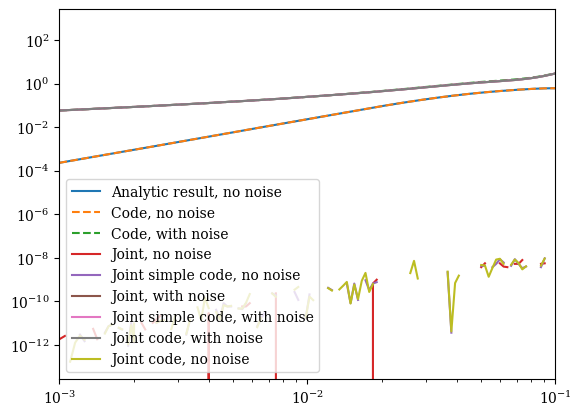

In [17]:
derivative = jax.jacfwd(bias_temp_function)(0.)
FF = 0.5*(derivative/bias_temp_function(0))**2
err = FF**-0.5
plt.loglog(Ks, err, label = "Analytic result, no noise")

plt.loglog(Ks, errO_no_var, ls = "--", label = "Code, no noise")
plt.loglog(Ks, errO, ls = "--", label = "Code, with noise")

plt.loglog(Ks, err_joint_no_noise, label = "Joint, no noise")
plt.loglog(Ks, err_joint_code_no_noise, label = "Joint simple code, no noise")
plt.loglog(Ks, err_joint_with_noise, label = "Joint, with noise")
plt.loglog(Ks, err_joint_code_with_noise, label = "Joint simple code, with noise")
plt.loglog(Ks, F[:, 0, 0]**-0.5, label = "Joint code, with noise")
plt.loglog(Ks, F_no_noise[:, 0, 0]**-0.5, label = "Joint code, no noise")

plt.legend()
plt.xlim(1e-3, 1e-1)

In [18]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)

Fint_no_var = fisher.get_F_integrated(Ks, FF_no_var.reshape(FF_no_var.size, 1, 1), k_min_analysis = k_min_analysis, k_max_analysis = 0.05, V = V)
Fint_analytical_no_noise = fisher.get_F_integrated(Ks, FF.reshape(FF.size, 1, 1), k_min_analysis = k_min_analysis, k_max_analysis = 0.05, V = V)
Fint_with_var = fisher.get_F_integrated(Ks, FF_with_var.reshape(FF_with_var.size, 1, 1), k_min_analysis = k_min_analysis, k_max_analysis = 0.05, V = V)
Fint_with_var_boost_kmax = fisher.get_F_integrated(Ks, FF_with_var.reshape(FF_with_var.size, 1, 1), k_min_analysis = k_min_analysis, k_max_analysis = 0.15, V = V)


/users/odarwish/lenscarf/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [19]:
Fint_no_var**-0.5, Fint_analytical_no_noise**-0.5, Fint_with_var**-0.5, Fint_with_var_boost_kmax**-0.5

(Array([[0.00090257]], dtype=float64),
 Array([[0.00090257]], dtype=float64),
 Array([[0.00702087]], dtype=float64),
 Array([[0.00456699]], dtype=float64))

## Full exploration

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_96354/3707633185.py:3: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


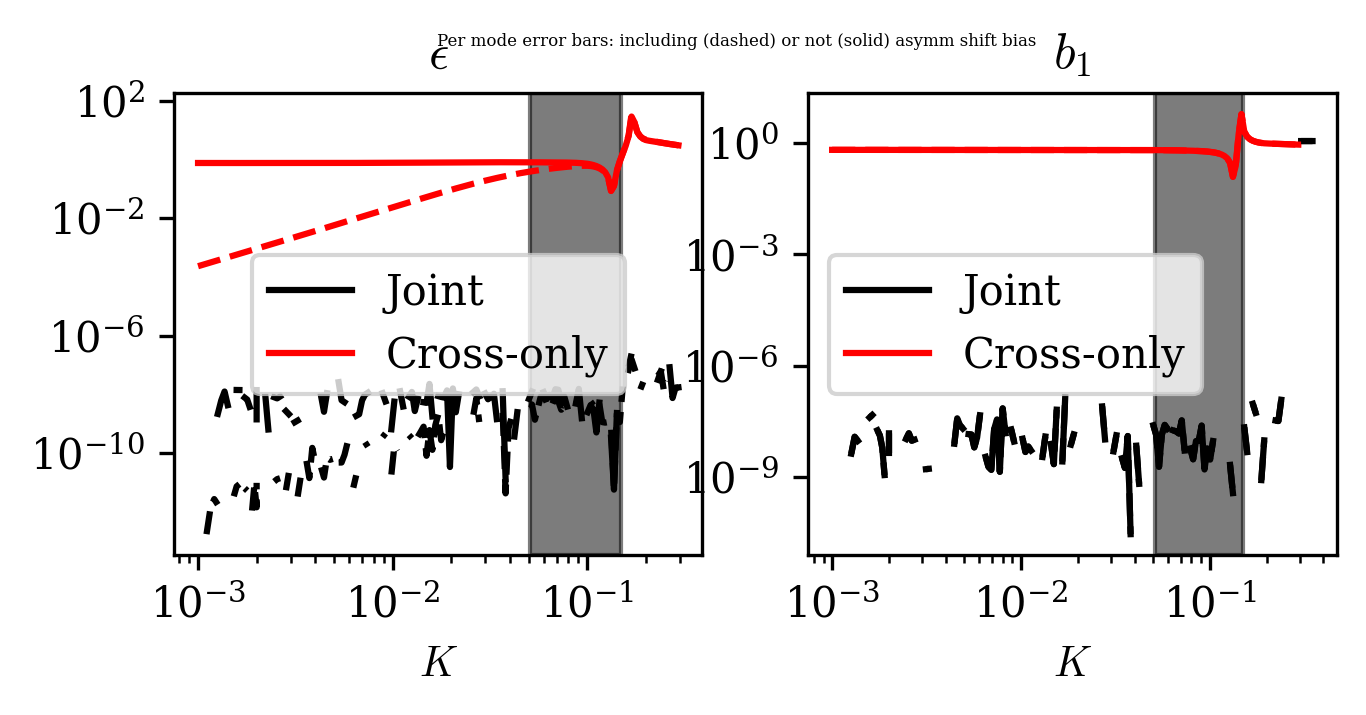

In [20]:
indices = [0, 1]
fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=plot.DPI, facecolor='white')
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for index_case, asymm_shift in enumerate([0, 1]):
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if index_case == 0 else None, color = "black", ls = "-" if index_case == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if index_case == 0 else None, ls = "-" if index_case == 0 else "--")
        ax.set_xlabel("$K$")
        #ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()
#fig.tight_layout()